In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully')

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully


In [ ]:
base = os.path.join(
    os.path.expanduser('~'), 'Desktop',
    'Credit-Risk-Analytics-Portfolio',
    '02_data_cleaning_pipeline'
)

# Find the raw file
raw_folder = os.path.join(base, 'data', 'raw')
files = os.listdir(raw_folder)
print(f'Files in raw folder: {files}')

# Load the CSV
# skipfooter skips last 2 rows which are footnotes in Lending Club data
raw_file = os.path.join(raw_folder, files[0])

print(f'\nLoading: {raw_file}')
print('This may take 1-2 minutes for large file...')

df = pd.read_csv(
    raw_file,
    
    skipfooter=2,
    engine='python'
)

print(f'\nData loaded successfully')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Files in raw folder: ['lending_club_raw.csv']

Loading: /Users/shivamverma/Desktop/Credit-Risk-Analytics-Portfolio/02_data_cleaning_pipeline/data/raw/lending_club_raw.csv
This may take 1-2 minutes for large file...


In [4]:
base = os.path.join(
    os.path.expanduser('~'), 'Desktop',
    'Credit-Risk-Analytics-Portfolio',
    '02_data_cleaning_pipeline'
)

# Find the raw file automatically
raw_folder = os.path.join(base, 'data', 'raw')
files      = [f for f in os.listdir(raw_folder) if f.endswith('.csv')]
raw_file   = os.path.join(raw_folder, files[0])

print(f'Loading: {raw_file}')

# Only load columns we actually need for the dashboard
# This reduces memory and loading time significantly
usecols = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate',
    'installment', 'grade', 'sub_grade', 'emp_length',
    'home_ownership', 'annual_inc', 'loan_status',
    'dti', 'addr_state', 'issue_d', 'purpose',
    'verification_status', 'application_type',
    'mort_acc', 'pub_rec', 'revol_bal',
    'revol_util', 'total_acc', 'initial_list_status',
    'open_acc', 'delinq_2yrs', 'earliest_cr_line'
]

print('Loading selected columns only — much faster...')

df = pd.read_csv(
    raw_file,
    usecols=lambda col: col in usecols,
    skiprows=lambda x: x > 0 and x % 3 != 0  # load every 3rd row = sample
)

print(f'\nData loaded successfully')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')

Loading: /Users/shivamverma/Desktop/Credit-Risk-Analytics-Portfolio/02_data_cleaning_pipeline/data/raw/lending_club_raw.csv
Loading selected columns only — much faster...

Data loaded successfully
Shape: 753,567 rows x 26 columns
Memory: 704.1 MB


In [5]:
# First 3 rows
print('First 3 rows:')
df.head(3)

First 3 rows:


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc
0,20000.0000,20000.0000,60 months,10.7800,432.6600,B,B4,10+ years,MORTGAGE,63000.0000,Not Verified,Dec-2015,Fully Paid,home_improvement,IL,10.7800,0.0000,Aug-2000,6.0000,0.0000,7869.0000,56.2000,18.0000,w,Joint App,5.0000
1,11950.0000,11950.0000,36 months,13.4400,405.1800,C,C3,4 years,RENT,34000.0000,Source Verified,Dec-2015,Fully Paid,debt_consolidation,GA,10.2000,0.0000,Oct-1987,5.0000,0.0000,8822.0000,68.4000,6.0000,w,Individual,0.0000
2,10000.0000,10000.0000,36 months,6.4900,306.4500,A,A2,6 years,RENT,85000.0000,Not Verified,Dec-2015,Fully Paid,credit_card,PA,13.0700,0.0000,Apr-2002,14.0000,1.0000,10464.0000,34.5000,23.0000,w,Individual,1.0000


In [6]:
# Data types summary
dtype_counts = df.dtypes.value_counts()
print('Data Type Summary')
print('='*35)
print(dtype_counts)
print(f'\nTotal columns : {df.shape[1]}')
print(f'Total rows    : {df.shape[0]:,}')
print(f'Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Data Type Summary
float64    13
object     13
Name: count, dtype: int64

Total columns : 26
Total rows    : 753,567
Memory usage  : 704.1 MB


In [7]:
# All column names
print('All columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:3}. {col}')

All columns:
    1. loan_amnt
    2. funded_amnt
    3. term
    4. int_rate
    5. installment
    6. grade
    7. sub_grade
    8. emp_length
    9. home_ownership
   10. annual_inc
   11. verification_status
   12. issue_d
   13. loan_status
   14. purpose
   15. addr_state
   16. dti
   17. delinq_2yrs
   18. earliest_cr_line
   19. open_acc
   20. pub_rec
   21. revol_bal
   22. revol_util
   23. total_acc
   24. initial_list_status
   25. application_type
   26. mort_acc


In [8]:
# Identify columns that look numerical but are stored as object
# These need type conversion in preprocessing

suspicious_cols = []

for col in df.select_dtypes(include='object').columns:
    sample = df[col].dropna().head(5).tolist()
    suspicious_cols.append({
        'Column'    : col,
        'Dtype'     : str(df[col].dtype),
        'Sample'    : str(sample),
        'Unique'    : df[col].nunique(),
        'Missing_%' : round(df[col].isnull().mean() * 100, 2)
    })

obj_df = pd.DataFrame(suspicious_cols)

print(f'Object (text) columns: {len(obj_df)}')
print('='*80)
print(obj_df[['Column','Sample','Unique','Missing_%']].to_string(index=False))

Object (text) columns: 13
             Column                                                                                                Sample  Unique  Missing_%
               term                                [' 60 months', ' 36 months', ' 36 months', ' 60 months', ' 36 months']       2     0.0000
              grade                                                                             ['B', 'C', 'A', 'C', 'A']       7     0.0000
          sub_grade                                                                        ['B4', 'C3', 'A2', 'C2', 'A2']      35     0.0000
         emp_length                                            ['10+ years', '4 years', '6 years', '1 year', '10+ years']      11     6.4800
     home_ownership                                                  ['MORTGAGE', 'RENT', 'RENT', 'MORTGAGE', 'MORTGAGE']       6     0.0000
verification_status                   ['Not Verified', 'Source Verified', 'Not Verified', 'Not Verified', 'Not Verified']       

In [9]:
# Specifically check columns with % signs, month labels etc.
# These are confirmed type conversion candidates

print('KEY TYPE ISSUES FOUND:')
print('='*55)

# Check for percentage columns
for col in df.select_dtypes(include='object').columns:
    sample = str(df[col].dropna().iloc[0]) if df[col].notna().any() else ''
    if '%' in sample:
        print(f'  PERCENTAGE: {col:<30} Sample: {sample}')
    elif 'months' in sample.lower():
        print(f'  MONTHS TEXT: {col:<30} Sample: {sample}')
    elif 'years' in sample.lower():
        print(f'  YEARS TEXT:  {col:<30} Sample: {sample}')

KEY TYPE ISSUES FOUND:
  MONTHS TEXT: term                           Sample:  60 months
  YEARS TEXT:  emp_length                     Sample: 10+ years


In [10]:
# Complete missing value audit
missing = pd.DataFrame({
    'Column'     : df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_%'  : (df.isnull().mean() * 100).round(2).values,
    'Dtype'      : df.dtypes.values
})

missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)

# Categorise severity
def missing_severity(pct):
    if pct > 80:   return 'Critical - Drop'
    elif pct > 40: return 'High - Review'
    elif pct > 10: return 'Medium - Impute'
    else:          return 'Low - Impute'

missing['Severity'] = missing['Missing_%'].apply(missing_severity)

print(f'Columns with missing values: {len(missing)} of {df.shape[1]}')
print('='*75)
print(missing.to_string(index=False))

Columns with missing values: 26 of 26
             Column  Missing_Count  Missing_%   Dtype     Severity
         emp_length          48826     6.4800  object Low - Impute
           mort_acc          16685     2.2100 float64 Low - Impute
         revol_util            597     0.0800 float64 Low - Impute
                dti            553     0.0700 float64 Low - Impute
         addr_state             10     0.0000  object Low - Impute
   application_type             10     0.0000  object Low - Impute
initial_list_status             10     0.0000  object Low - Impute
          total_acc             18     0.0000 float64 Low - Impute
          revol_bal             10     0.0000 float64 Low - Impute
            pub_rec             18     0.0000 float64 Low - Impute
           open_acc             18     0.0000 float64 Low - Impute
   earliest_cr_line             18     0.0000  object Low - Impute
        delinq_2yrs             18     0.0000 float64 Low - Impute
          loan_amnt     

Missing Value Severity Summary
Severity
Low - Impute    26


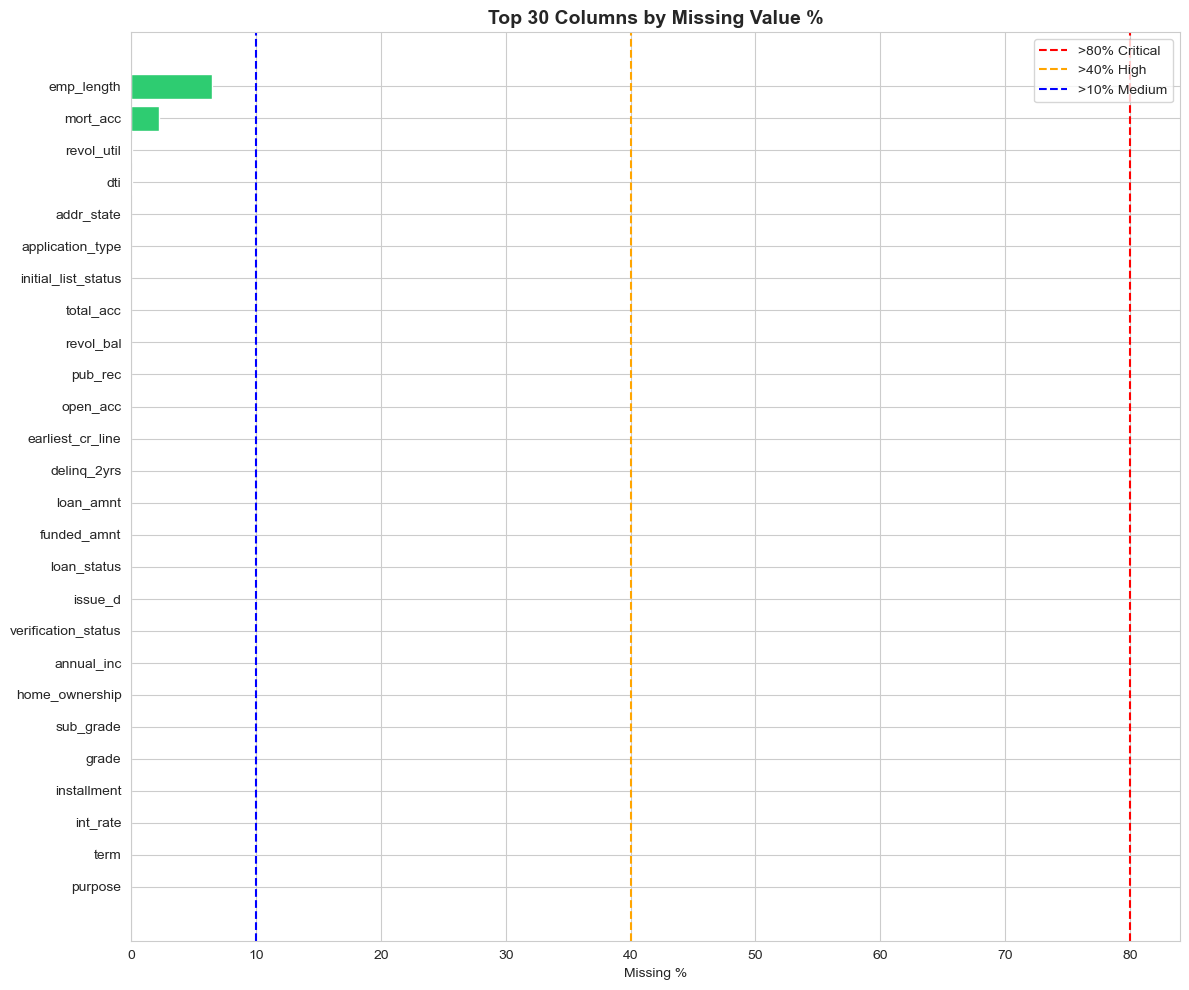

Chart saved


In [11]:
# Missing value severity summary
severity_summary = missing['Severity'].value_counts()
print('Missing Value Severity Summary')
print('='*40)
print(severity_summary.to_string())

# Missing value chart
top30_missing = missing.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
colors = [
    '#e74c3c' if x > 80 else
    '#f39c12' if x > 40 else
    '#3498db' if x > 10 else
    '#2ecc71'
    for x in top30_missing['Missing_%']
]

ax.barh(top30_missing['Column'], top30_missing['Missing_%'],
        color=colors, edgecolor='white')
ax.axvline(x=80, color='red',    linestyle='--', linewidth=1.5, label='>80% Critical')
ax.axvline(x=40, color='orange', linestyle='--', linewidth=1.5, label='>40% High')
ax.axvline(x=10, color='blue',   linestyle='--', linewidth=1.5, label='>10% Medium')
ax.set_xlabel('Missing %')
ax.set_title('Top 30 Columns by Missing Value %', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '01_missing_values.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

Missing Value Severity Summary
Severity
Low - Impute    26


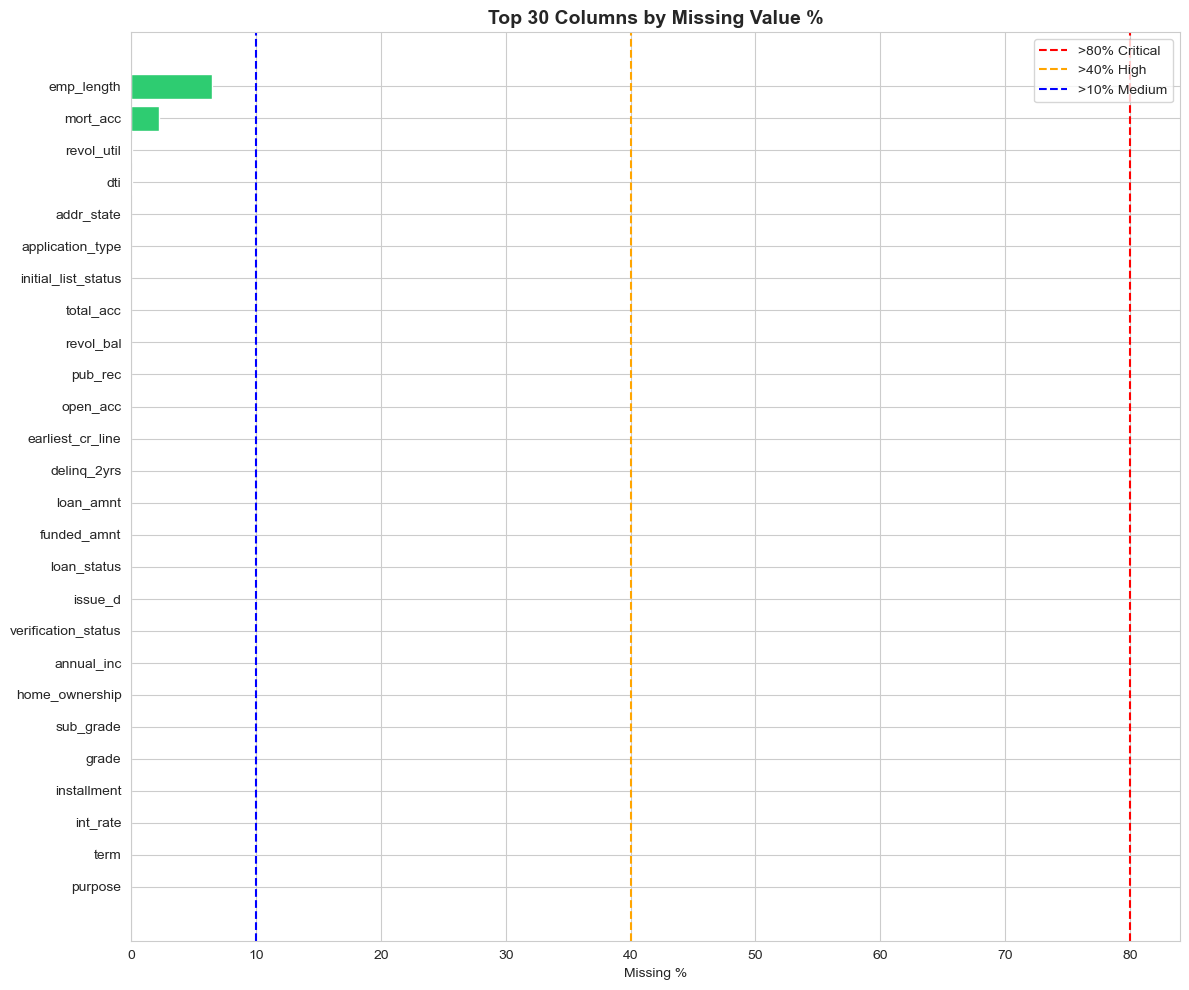

Chart saved


In [12]:
# Missing value severity summary
severity_summary = missing['Severity'].value_counts()
print('Missing Value Severity Summary')
print('='*40)
print(severity_summary.to_string())

# Missing value chart
top30_missing = missing.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
colors = [
    '#e74c3c' if x > 80 else
    '#f39c12' if x > 40 else
    '#3498db' if x > 10 else
    '#2ecc71'
    for x in top30_missing['Missing_%']
]

ax.barh(top30_missing['Column'], top30_missing['Missing_%'],
        color=colors, edgecolor='white')
ax.axvline(x=80, color='red',    linestyle='--', linewidth=1.5, label='>80% Critical')
ax.axvline(x=40, color='orange', linestyle='--', linewidth=1.5, label='>40% High')
ax.axvline(x=10, color='blue',   linestyle='--', linewidth=1.5, label='>10% Medium')
ax.set_xlabel('Missing %')
ax.set_title('Top 30 Columns by Missing Value %', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '01_missing_values.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

In [13]:
# Check for duplicate rows
total_dupes = df.duplicated().sum()
print(f'Exact duplicate rows: {total_dupes:,}')
print(f'Duplicate rate      : {total_dupes/len(df)*100:.4f}%')

# Check for duplicate loan IDs
if 'id' in df.columns:
    id_dupes = df['id'].duplicated().sum()
    print(f'\nDuplicate loan IDs  : {id_dupes:,}')

# Check for duplicate member IDs
if 'member_id' in df.columns:
    member_dupes = df['member_id'].duplicated().sum()
    null_member  = df['member_id'].isnull().sum()
    print(f'Duplicate member IDs: {member_dupes:,}')
    print(f'Null member IDs     : {null_member:,}')

Exact duplicate rows: 9
Duplicate rate      : 0.0012%


In [14]:
# Key columns to inspect
key_cols = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate',
    'installment', 'grade', 'sub_grade', 'emp_length',
    'home_ownership', 'annual_inc', 'loan_status',
    'dti', 'addr_state', 'issue_d', 'purpose'
]

# Filter to columns that actually exist in this dataset
key_cols = [c for c in key_cols if c in df.columns]

print('KEY COLUMN AUDIT')
print('='*75)

for col in key_cols:
    dtype    = df[col].dtype
    missing  = df[col].isnull().sum()
    miss_pct = df[col].isnull().mean() * 100
    unique   = df[col].nunique()
    sample   = df[col].dropna().head(3).tolist()

    print(f'\n  {col}')
    print(f'    Type     : {dtype}')
    print(f'    Missing  : {missing:,} ({miss_pct:.2f}%)')
    print(f'    Unique   : {unique:,}')
    print(f'    Sample   : {sample}')

KEY COLUMN AUDIT

  loan_amnt
    Type     : float64
    Missing  : 10 (0.00%)
    Unique   : 1,563
    Sample   : [20000.0, 11950.0, 10000.0]

  funded_amnt
    Type     : float64
    Missing  : 10 (0.00%)
    Unique   : 1,563
    Sample   : [20000.0, 11950.0, 10000.0]

  term
    Type     : object
    Missing  : 10 (0.00%)
    Unique   : 2
    Sample   : [' 60 months', ' 36 months', ' 36 months']

  int_rate
    Type     : float64
    Missing  : 10 (0.00%)
    Unique   : 651
    Sample   : [10.78, 13.44, 6.49]

  installment
    Type     : float64
    Missing  : 10 (0.00%)
    Unique   : 69,850
    Sample   : [432.66, 405.18, 306.45]

  grade
    Type     : object
    Missing  : 10 (0.00%)
    Unique   : 7
    Sample   : ['B', 'C', 'A']

  sub_grade
    Type     : object
    Missing  : 10 (0.00%)
    Unique   : 35
    Sample   : ['B4', 'C3', 'A2']

  emp_length
    Type     : object
    Missing  : 48,826 (6.48%)
    Unique   : 11
    Sample   : ['10+ years', '4 years', '6 years']

  

In [15]:
# Loan status distribution
loan_status_counts = df['loan_status'].value_counts()
loan_status_pct    = df['loan_status'].value_counts(normalize=True) * 100

loan_status_df = pd.DataFrame({
    'Count'  : loan_status_counts,
    'Pct_%'  : loan_status_pct.round(2)
})

print('Loan Status Distribution')
print('='*55)
print(loan_status_df.to_string())

# Define how we will simplify these into 3 categories for dashboard
print('\nPROPOSED MAPPING FOR DASHBOARD')
print('='*55)
mapping = {
    'Fully Paid'                                    : 'Good',
    'Current'                                       : 'Current',
    'Charged Off'                                   : 'Bad',
    'Late (31-120 days)'                            : 'Bad',
    'Issued'                                        : 'Current',
    'In Grace Period'                               : 'Watch',
    'Late (16-30 days)'                             : 'Watch',
    'Does not meet the credit policy. Status:Fully Paid': 'Good',
    'Does not meet the credit policy. Status:Charged Off': 'Bad',
    'Default'                                       : 'Bad'
}
for status, group in mapping.items():
    if status in loan_status_counts.index:
        print(f'  {status:<55} -> {group}')

Loan Status Distribution
                                                      Count   Pct_%
loan_status                                                        
Fully Paid                                           358521 47.5800
Current                                              293196 38.9100
Charged Off                                           89582 11.8900
Late (31-120 days)                                     7161  0.9500
In Grace Period                                        2773  0.3700
Late (16-30 days)                                      1392  0.1800
Does not meet the credit policy. Status:Fully Paid      657  0.0900
Does not meet the credit policy. Status:Charged Off     259  0.0300
Default                                                  16  0.0000

PROPOSED MAPPING FOR DASHBOARD
  Fully Paid                                              -> Good
  Current                                                 -> Current
  Charged Off                                             ->

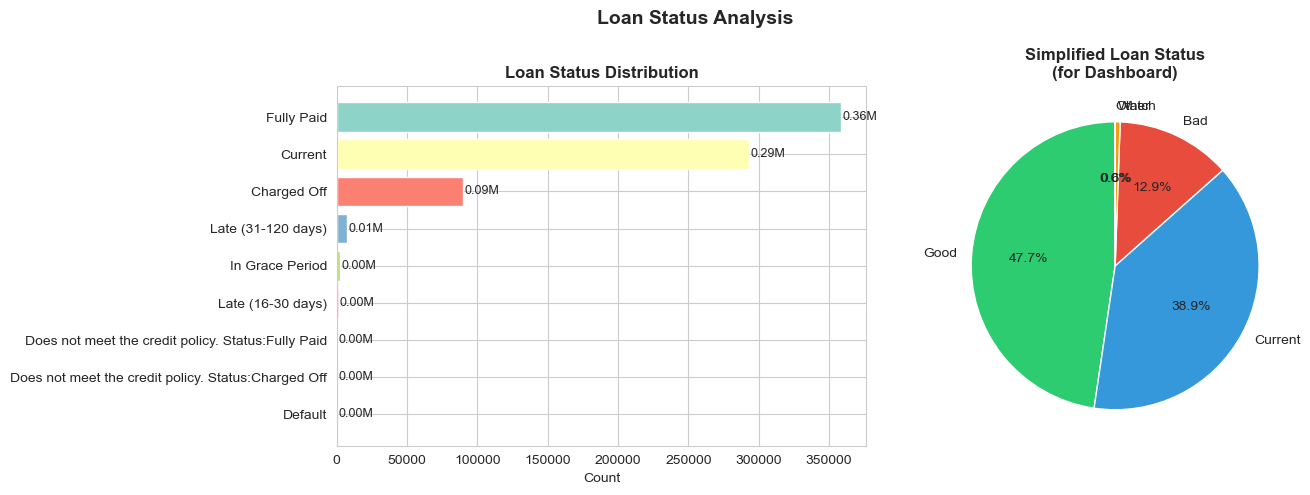

Chart saved


In [16]:
# Loan status chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_status = plt.cm.Set3(np.linspace(0, 1, len(loan_status_counts)))
axes[0].barh(loan_status_counts.index, loan_status_counts.values,
             color=colors_status, edgecolor='white')
axes[0].set_xlabel('Count')
axes[0].set_title('Loan Status Distribution', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(loan_status_counts.values):
    axes[0].text(v + 1000, i, f'{v/1e6:.2f}M', va='center', fontsize=9)

# Simplified status pie chart
df['loan_status_simple'] = df['loan_status'].map(mapping).fillna('Other')
simple_counts = df['loan_status_simple'].value_counts()
colors_pie = {'Good': '#2ecc71', 'Bad': '#e74c3c',
              'Current': '#3498db', 'Watch': '#f39c12', 'Other': '#95a5a6'}
pie_colors = [colors_pie.get(s, '#95a5a6') for s in simple_counts.index]

axes[1].pie(simple_counts.values, labels=simple_counts.index,
            autopct='%1.1f%%', colors=pie_colors, startangle=90)
axes[1].set_title('Simplified Loan Status\n(for Dashboard)', fontsize=12, fontweight='bold')

plt.suptitle('Loan Status Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '02_loan_status.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

In [17]:
# Statistical summary of key numerical columns
num_key_cols = ['loan_amnt', 'funded_amnt', 'installment', 'annual_inc', 'dti']
num_key_cols = [c for c in num_key_cols if c in df.columns]

print('Key Numerical Variables - Statistical Summary')
print('='*65)
print(df[num_key_cols].describe().T.round(2).to_string())

Key Numerical Variables - Statistical Summary
                  count       mean        std      min        25%        50%        75%           max
loan_amnt   753557.0000 15039.5800  9188.7800 500.0000  8000.0000 12875.0000 20000.0000    40000.0000
funded_amnt 753557.0000 15034.3300  9187.1800 500.0000  8000.0000 12825.0000 20000.0000    40000.0000
installment 753557.0000   445.4600   266.9600   7.6100   251.6100   377.7200   592.7600     1714.5400
annual_inc  753557.0000 77950.6800 79332.2500   0.0000 46000.0000 65000.0000 93000.0000 10999200.0000
dti         753014.0000    18.8200    14.0600   0.0000    11.9100    17.8300    24.4900      999.0000


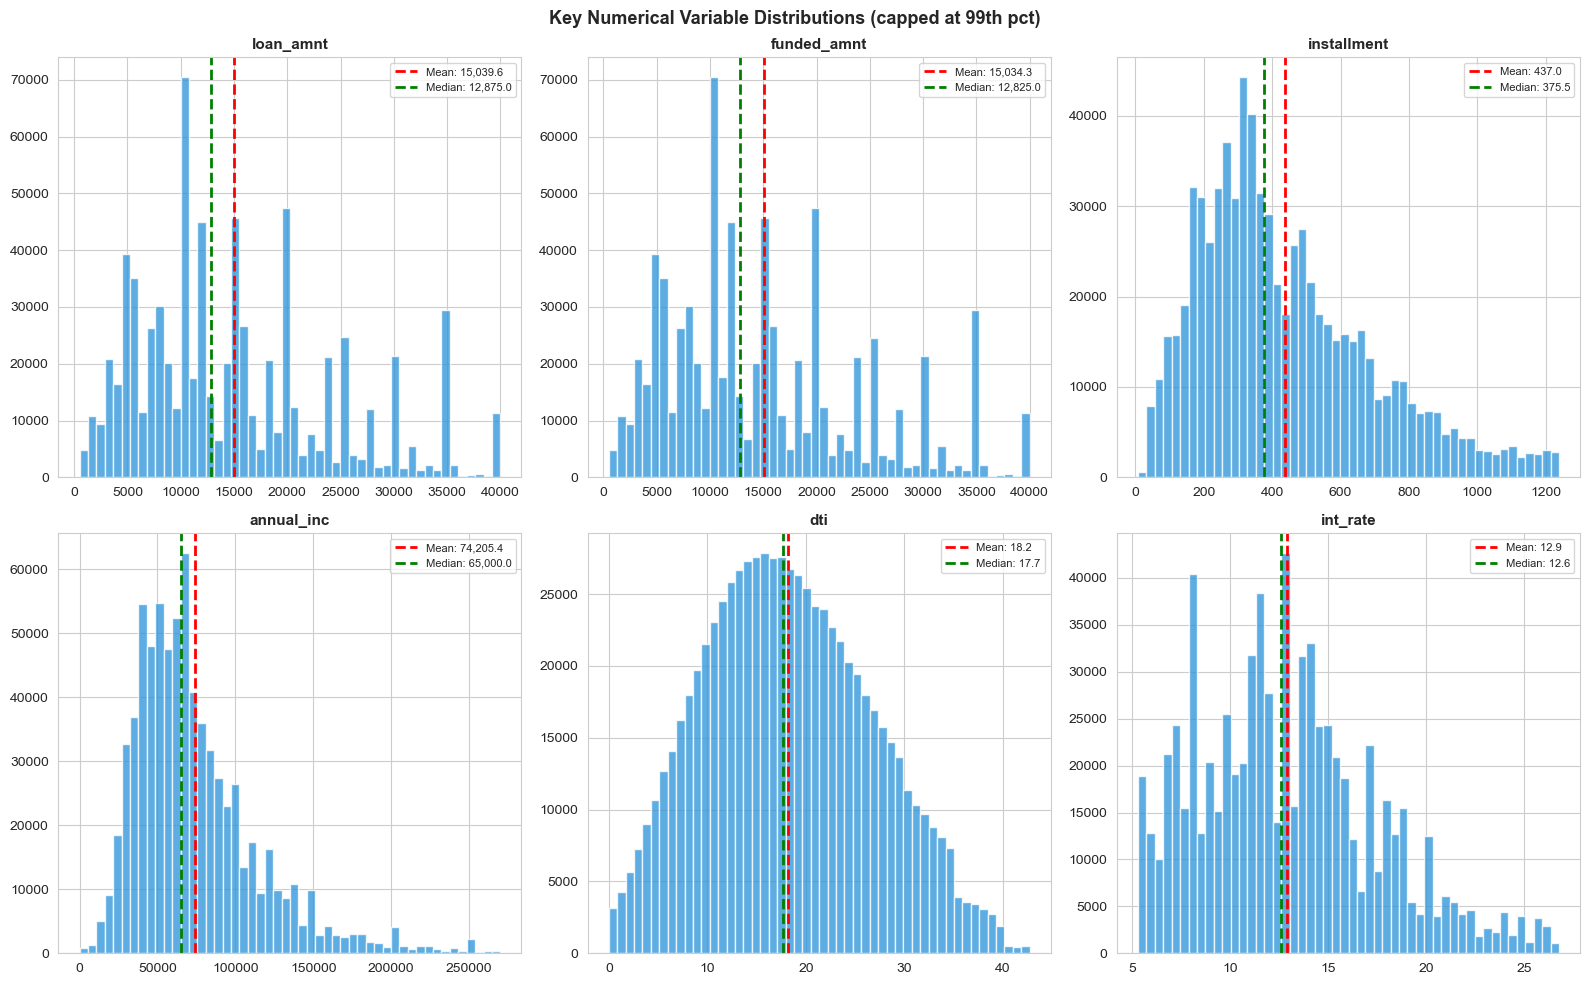

Chart saved


In [18]:
# Distribution charts for key numerical variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_cols = ['loan_amnt', 'funded_amnt', 'installment',
             'annual_inc', 'dti', 'int_rate']
plot_cols = [c for c in plot_cols if c in df.columns]

for i, col in enumerate(plot_cols):
    # Handle percentage columns stored as text
    if df[col].dtype == 'object':
        data = pd.to_numeric(
            df[col].str.replace('%', '').str.strip(),
            errors='coerce'
        ).dropna()
    else:
        data = df[col].dropna()

    # Cap at 99th percentile for display
    cap = data.quantile(0.99)
    data = data[data <= cap]

    axes[i].hist(data, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(),   color='red',   linestyle='--',
                    linewidth=2, label=f'Mean: {data.mean():,.1f}')
    axes[i].axvline(data.median(), color='green', linestyle='--',
                    linewidth=2, label=f'Median: {data.median():,.1f}')
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Key Numerical Variable Distributions (capped at 99th pct)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '03_numerical_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

In [19]:
# Cardinality analysis for all categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

cardinality = []
for col in cat_cols:
    unique_count = df[col].nunique()
    top_value    = df[col].value_counts().index[0] if df[col].notna().any() else 'N/A'
    top_pct      = df[col].value_counts(normalize=True).iloc[0] * 100 if df[col].notna().any() else 0

    if unique_count > 1000:
        action = 'Group or Drop - too many categories'
    elif unique_count > 50:
        action = 'Review - high cardinality'
    elif unique_count > 10:
        action = 'Usable - moderate cardinality'
    else:
        action = 'Good - low cardinality'

    cardinality.append({
        'Column'    : col,
        'Unique'    : unique_count,
        'Top_Value' : str(top_value)[:30],
        'Top_%'     : round(top_pct, 1),
        'Action'    : action
    })

card_df = pd.DataFrame(cardinality).sort_values('Unique', ascending=False)

print('CATEGORICAL CARDINALITY ANALYSIS')
print('='*80)
print(card_df.to_string(index=False))

CATEGORICAL CARDINALITY ANALYSIS
             Column  Unique          Top_Value   Top_%                        Action
   earliest_cr_line     715           Sep-2004  0.7000     Review - high cardinality
            issue_d     139           Mar-2016  2.7000     Review - high cardinality
         addr_state      51                 CA 13.9000     Review - high cardinality
          sub_grade      35                 C1  6.5000 Usable - moderate cardinality
            purpose      14 debt_consolidation 56.5000 Usable - moderate cardinality
         emp_length      11          10+ years 35.4000 Usable - moderate cardinality
        loan_status       9         Fully Paid 47.6000        Good - low cardinality
              grade       7                  B 29.3000        Good - low cardinality
     home_ownership       6           MORTGAGE 49.2000        Good - low cardinality
 loan_status_simple       5               Good 47.7000        Good - low cardinality
verification_status       3    S

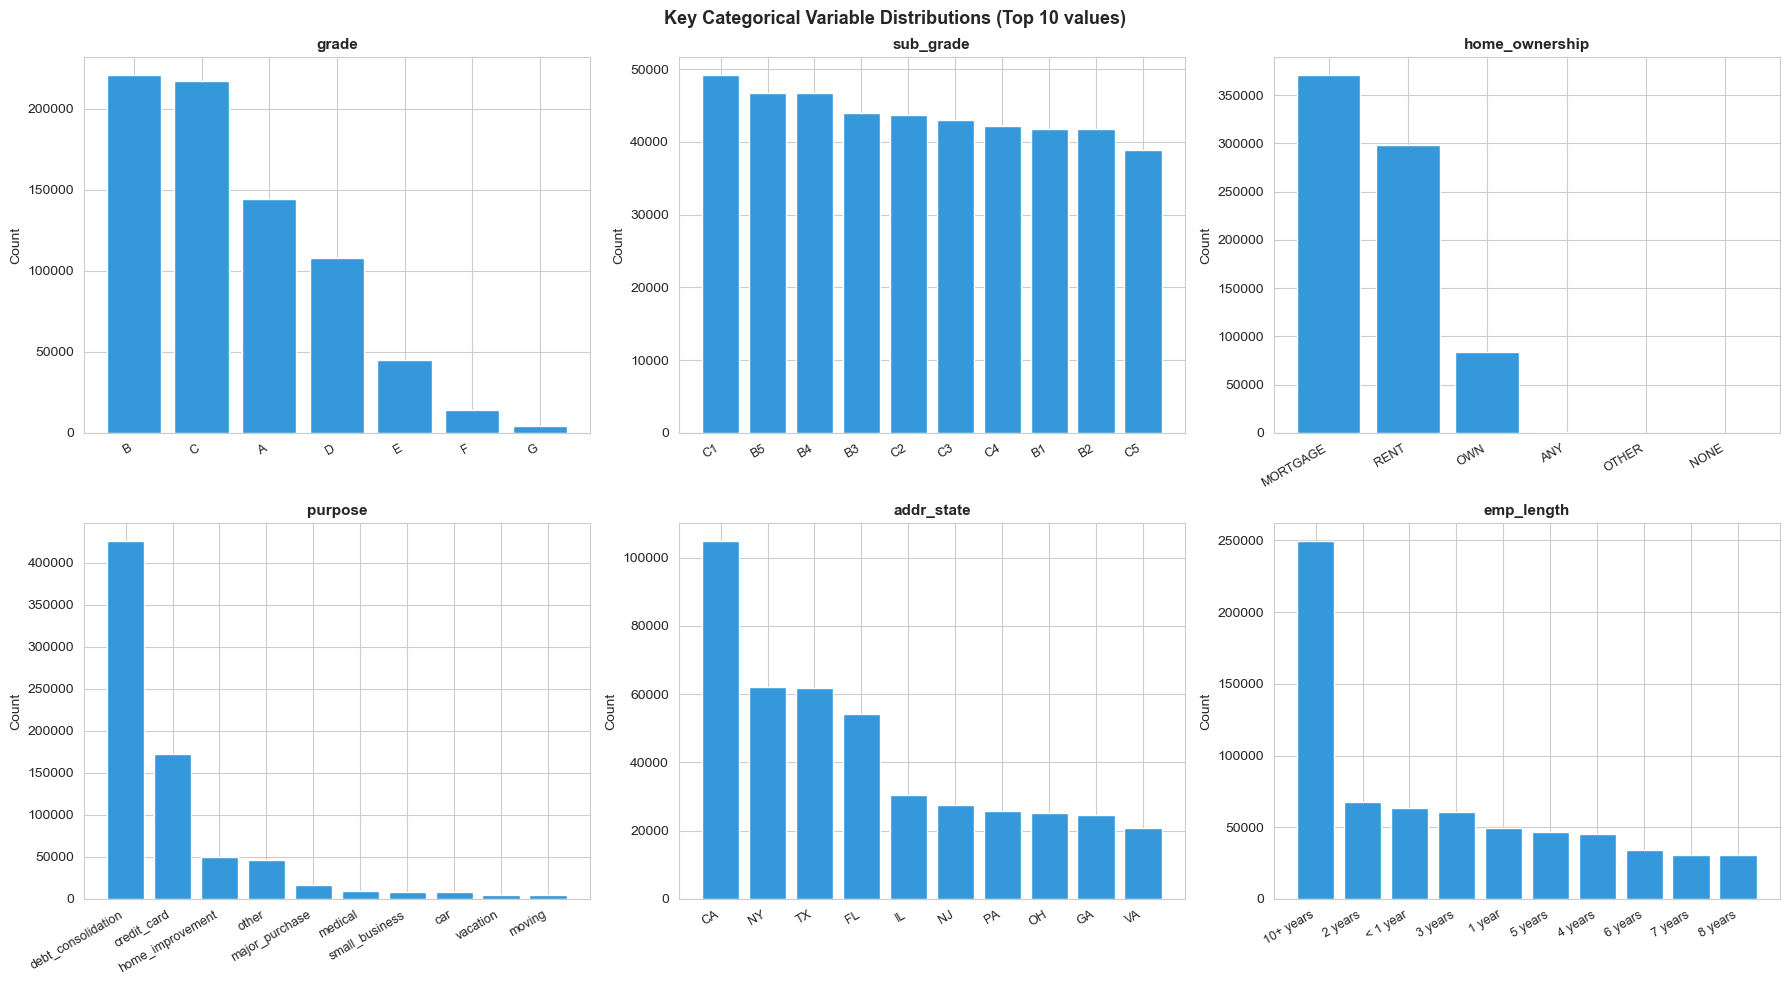

Chart saved


In [20]:
# Key categorical columns - value counts
key_cat_cols = ['grade', 'sub_grade', 'home_ownership',
                'purpose', 'addr_state', 'emp_length']
key_cat_cols = [c for c in key_cat_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_cat_cols):
    counts = df[col].value_counts().head(10)
    axes[i].bar(range(len(counts)), counts.values,
                color='#3498db', edgecolor='white')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')

plt.suptitle('Key Categorical Variable Distributions (Top 10 values)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base, 'outputs', '04_categorical_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

In [21]:
# Build comprehensive data quality report
quality_report = []

for col in df.columns:
    dtype      = str(df[col].dtype)
    miss_count = df[col].isnull().sum()
    miss_pct   = round(df[col].isnull().mean() * 100, 2)
    unique     = df[col].nunique()
    sample     = str(df[col].dropna().iloc[0]) if df[col].notna().any() else 'ALL NULL'

    # Detect issues
    issues = []
    if miss_pct > 80:  issues.append('HIGH MISSING')
    if miss_pct > 0:   issues.append(f'MISSING {miss_pct}%')
    if dtype == 'object' and '%' in sample: issues.append('PERCENTAGE AS TEXT')
    if dtype == 'object' and 'months' in sample.lower(): issues.append('DURATION AS TEXT')
    if dtype == 'object' and 'years' in sample.lower():  issues.append('YEARS AS TEXT')
    if unique > 1000 and dtype == 'object': issues.append('HIGH CARDINALITY')
    if unique == 1:  issues.append('CONSTANT - DROP')
    if unique == df.shape[0]: issues.append('UNIQUE ID')

    # Recommended action
    if miss_pct > 80:   action = 'DROP'
    elif unique == 1:   action = 'DROP - constant'
    elif '%' in sample: action = 'CONVERT - remove % sign'
    elif 'months' in sample.lower(): action = 'CONVERT - extract number'
    elif 'years' in sample.lower():  action = 'CONVERT - extract number'
    elif miss_pct > 0 and dtype != 'object': action = 'IMPUTE - median'
    elif miss_pct > 0 and dtype == 'object': action = 'IMPUTE - mode or MISSING'
    else: action = 'KEEP AS IS'

    quality_report.append({
        'Column'      : col,
        'Dtype'       : dtype,
        'Missing_Count': miss_count,
        'Missing_%'   : miss_pct,
        'Unique_Values': unique,
        'Sample'      : sample[:40],
        'Issues'      : ' | '.join(issues) if issues else 'None',
        'Action'      : action
    })

quality_df = pd.DataFrame(quality_report)
quality_df.to_csv(os.path.join(base, 'outputs', 'data_quality_report.csv'), index=False)

print('DATA QUALITY REPORT SAVED')
print('='*55)
print(f'Total columns analysed : {len(quality_df)}')
print(f'Columns to DROP        : {len(quality_df[quality_df["Action"]=="DROP"])}')
print(f'Columns to CONVERT     : {len(quality_df[quality_df["Action"].str.contains("CONVERT")])}')
print(f'Columns to IMPUTE      : {len(quality_df[quality_df["Action"].str.contains("IMPUTE")])}')
print(f'Columns OK             : {len(quality_df[quality_df["Action"]=="KEEP AS IS"])}')
print(f'\nFull report saved to: outputs/data_quality_report.csv')

DATA QUALITY REPORT SAVED
Total columns analysed : 27
Columns to DROP        : 0
Columns to CONVERT     : 2
Columns to IMPUTE      : 3
Columns OK             : 22

Full report saved to: outputs/data_quality_report.csv
